<a href="https://colab.research.google.com/github/JOteng15/Quantum-walk-vs-Classical-walk/blob/main/QuantumVSClassical.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Running Quantum Random Walk Simulation...

  Quantum Random Walk — Key Results

  t =  25 steps:
    Classical σ  ≈ 5.03  (expected √25 = 5.00)
    Quantum   σ  ≈ 13.55  (expected ~8.8 × t)
    Speedup ratio: 2.69×

  t =  50 steps:
    Classical σ  ≈ 7.10  (expected √50 = 7.07)
    Quantum   σ  ≈ 27.07  (expected ~17.5 × t)
    Speedup ratio: 3.81×

  t = 100 steps:
    Classical σ  ≈ 10.05  (expected √100 = 10.00)
    Quantum   σ  ≈ 54.12  (expected ~35.0 × t)
    Speedup ratio: 5.39×

  Interpretation:
  Classical walk spreads as σ ~ √t  (diffusive)
  Quantum  walk spreads as σ ~ t    (ballistic)
  → Quadratic speedup underlies Grover's algorithm.

Generating figures...
Done. Output saved to quantum_random_walk.png


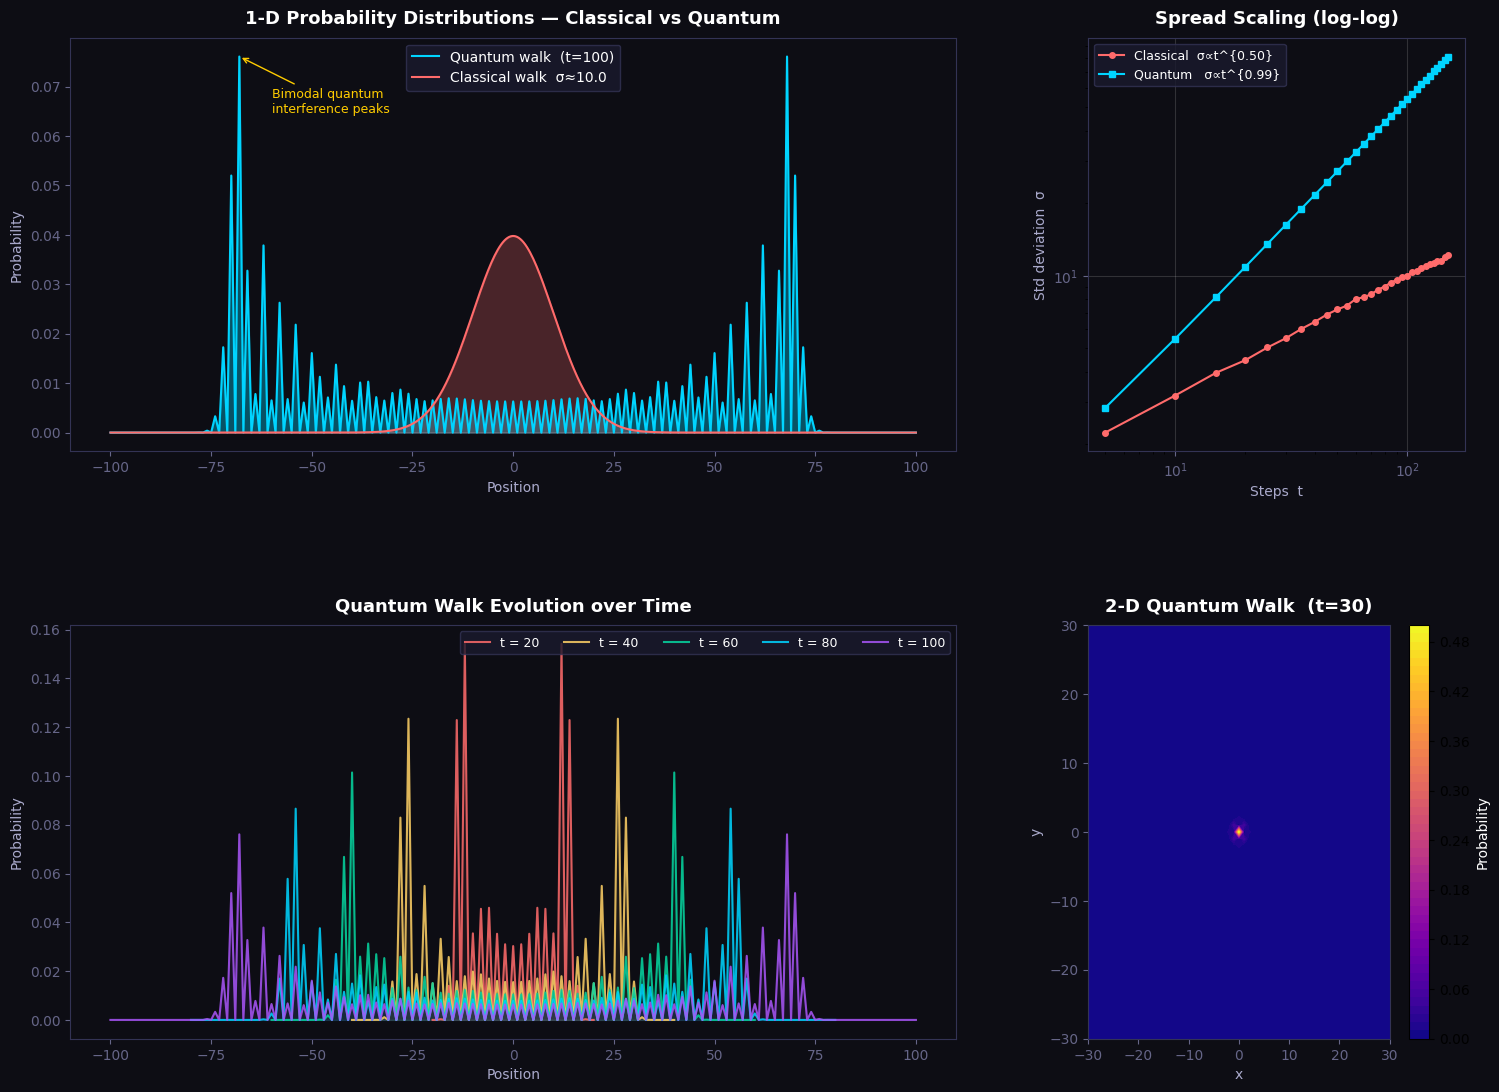

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import norm
import os

# ─────────────────────────────────────────────
# 1.  CLASSICAL RANDOM WALK (1D)
# ─────────────────────────────────────────────

def classical_random_walk(n_steps: int, n_trials: int = 5000) -> np.ndarray:
    """
    Monte-Carlo simulation of a 1D classical random walk.
    At each step the walker moves ±1 with equal probability.

    Returns array of final positions shape (n_trials).
    """
    rng = np.random.default_rng(seed=42)
    steps = rng.choice([-1, 1], size=(n_trials, n_steps))
    return steps.cumsum(axis=1)          # shape: (n_trials, n_steps)


# ─────────────────────────────────────────────
# 2.  QUANTUM RANDOM WALK (1D) – Hadamard coin
# ─────────────────────────────────────────────

def quantum_random_walk_1d(n_steps: int) -> tuple[np.ndarray, np.ndarray]:
    """
    Discrete-time quantum random walk on the integer line.

    State space: |position⟩ ⊗ |coin⟩  where coin ∈ {↑, ↓}

    Coin operator: Hadamard  H = 1/√2 [[1, 1], [1,-1]]
    Shift operator: S|x,↑⟩ = |x+1,↑⟩,  S|x,↓⟩ = |x-1,↓⟩

    Initial state: |0⟩ ⊗ (|↑⟩ + i|↓⟩)/√2   (symmetric superposition)

    Returns:
        positions : array of integers  [-n_steps, ..., n_steps]
        probs     : probability distribution over positions
    """
    size = 2 * n_steps + 1          # position range: -n_steps … +n_steps
    origin = n_steps                 # index of position 0

    # State tensor: psi[pos, coin]   coin: 0=↑, 1=↓
    psi = np.zeros((size, 2), dtype=complex)
    # Symmetric initial coin state |0⟩ ⊗ (|↑⟩ + i|↓⟩)/√2
    psi[origin, 0] = 1.0 / np.sqrt(2)
    psi[origin, 1] = 1j / np.sqrt(2)

    H = np.array([[1, 1], [1, -1]], dtype=complex) / np.sqrt(2)   # Hadamard

    for _ in range(n_steps):
        # Apply coin (Hadamard) to every position
        psi = (H @ psi.T).T           # shape: (size, 2)

        # Shift: ↑ moves right (+1), ↓ moves left (−1)
        psi_new = np.zeros_like(psi)
        psi_new[1:,  0] = psi[:-1, 0]   # ↑  shifts right
        psi_new[:-1, 1] = psi[1:,  1]   # ↓  shifts left
        psi = psi_new

    probs = np.abs(psi[:, 0])**2 + np.abs(psi[:, 1])**2
    positions = np.arange(-n_steps, n_steps + 1)
    return positions, probs


# ─────────────────────────────────────────────
# 3.  STANDARD DEVIATION SCALING
# ─────────────────────────────────────────────

def compute_std_scaling(max_steps: int = 150, step_size: int = 5):
    """
    Measure how the spread (std) grows with t for CRW and QRW.

    CRW: σ ∝ √t   (diffusive)
    QRW: σ ∝  t   (ballistic — quadratic speedup)
    """
    steps_range = np.arange(step_size, max_steps + 1, step_size)
    crw_stds, qrw_stds = [], []

    for t in steps_range:
        # CRW std from simulation
        crw_positions = classical_random_walk(t, n_trials=3000)[:, -1]
        crw_stds.append(crw_positions.std())

        # QRW std from exact probability distribution
        pos, probs = quantum_random_walk_1d(t)
        mean = np.sum(pos * probs)
        qrw_stds.append(np.sqrt(np.sum((pos - mean)**2 * probs)))

    return steps_range, np.array(crw_stds), np.array(qrw_stds)


# ─────────────────────────────────────────────
# 4.  2-D QUANTUM RANDOM WALK  (Grover coin)
# ─────────────────────────────────────────────

def quantum_random_walk_2d(n_steps: int) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    2-D discrete-time QRW using a 4-dimensional Grover coin.

    Coin directions: 0=right (+x), 1=left (−x), 2=up (+y), 3=down (−y)
    Grover diffusion coin: G = (2/4)|s⟩⟨s| − I  where |s⟩ = uniform
    """
    size = 2 * n_steps + 1
    origin = n_steps

    # psi[x, y, coin_dir]
    psi = np.zeros((size, size, 4), dtype=complex)
    # Uniform coin superposition at origin
    psi[origin, origin, :] = 0.5 + 0j

    # Grover coin (4×4)
    G = np.full((4, 4), 0.5, dtype=complex) - np.eye(4, dtype=complex)

    dx = [1, -1, 0,  0]
    dy = [0,  0, 1, -1]

    for _ in range(n_steps):
        # Apply Grover coin
        psi_flat = psi.reshape(-1, 4)
        psi_flat = (G @ psi_flat.T).T
        psi = psi_flat.reshape(size, size, 4)

        # Shift in each direction
        psi_new = np.zeros_like(psi)
        for d in range(4):
            shifted = np.roll(np.roll(psi[:, :, d], dx[d], axis=0), dy[d], axis=1)
            psi_new[:, :, d] = shifted
        psi = psi_new

    probs_2d = np.sum(np.abs(psi)**2, axis=2)
    coords = np.arange(-n_steps, n_steps + 1)
    X, Y = np.meshgrid(coords, coords)
    return X, Y, probs_2d


# ─────────────────────────────────────────────
# 5.  VISUALISATION
# ─────────────────────────────────────────────

def plot_all(n_steps_dist: int = 100, n_steps_2d: int = 30):
    fig = plt.figure(figsize=(18, 13), facecolor="#0d0d14")
    gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.35)

    title_kw  = dict(color="white", fontsize=13, fontweight="bold", pad=10)
    label_kw  = dict(color="#aaaacc", fontsize=10)
    tick_kw   = dict(colors="#666688")

    # ── Panel A: 1-D probability distributions ──────────────────────────────
    ax1 = fig.add_subplot(gs[0, :2])

    pos_q, probs_q = quantum_random_walk_1d(n_steps_dist)
    crw_traj = classical_random_walk(n_steps_dist, n_trials=200000)[:, -1]
    crw_x = np.linspace(-n_steps_dist, n_steps_dist, 500)
    crw_sigma = np.std(crw_traj)
    crw_pdf = norm.pdf(crw_x, 0, crw_sigma)

    ax1.fill_between(pos_q, probs_q, alpha=0.35, color="#00d4ff")
    ax1.plot(pos_q, probs_q, color="#00d4ff", lw=1.5, label=f"Quantum walk  (t={n_steps_dist})")
    ax1.fill_between(crw_x, crw_pdf, alpha=0.25, color="#ff6b6b")
    ax1.plot(crw_x, crw_pdf, color="#ff6b6b", lw=1.5,
             label=f"Classical walk  σ≈{crw_sigma:.1f}")

    ax1.set_title("1-D Probability Distributions — Classical vs Quantum", **title_kw)
    ax1.set_xlabel("Position", **label_kw)
    ax1.set_ylabel("Probability", **label_kw)
    ax1.tick_params(colors=tick_kw["colors"])
    ax1.spines[:].set_color("#333355")
    ax1.set_facecolor("#0d0d14")
    legend = ax1.legend(facecolor="#1a1a2e", edgecolor="#333355", labelcolor="white",
                        fontsize=10)

    # annotation: bimodal peaks
    ax1.annotate("Bimodal quantum\ninterference peaks",
                 xy=(pos_q[np.argmax(probs_q[:len(pos_q)//2])], probs_q[:len(pos_q)//2].max()),
                 xytext=(-n_steps_dist*0.6, probs_q.max()*0.85),
                 arrowprops=dict(arrowstyle="->", color="#ffcc00"),
                 color="#ffcc00", fontsize=9)

    # ── Panel B: Standard deviation scaling ─────────────────────────────────
    ax2 = fig.add_subplot(gs[0, 2])
    steps_r, crw_s, qrw_s = compute_std_scaling()

    # Fit lines in log-log space
    log_t = np.log(steps_r)
    crw_slope = np.polyfit(log_t, np.log(crw_s), 1)[0]
    qrw_slope = np.polyfit(log_t, np.log(qrw_s), 1)[0]

    ax2.loglog(steps_r, crw_s, "o-", color="#ff6b6b", ms=4, lw=1.5,
               label=f"Classical  σ∝t^{{{crw_slope:.2f}}}")
    ax2.loglog(steps_r, qrw_s, "s-", color="#00d4ff", ms=4, lw=1.5,
               label=f"Quantum   σ∝t^{{{qrw_slope:.2f}}}")

    ax2.set_title("Spread Scaling (log-log)", **title_kw)
    ax2.set_xlabel("Steps  t", **label_kw)
    ax2.set_ylabel("Std deviation  σ", **label_kw)
    ax2.tick_params(colors=tick_kw["colors"])
    ax2.spines[:].set_color("#333355")
    ax2.set_facecolor("#0d0d14")
    ax2.legend(facecolor="#1a1a2e", edgecolor="#333355", labelcolor="white", fontsize=9)
    ax2.grid(True, alpha=0.15, color="white")

    # ── Panel C: Multiple time steps comparison ──────────────────────────────
    ax3 = fig.add_subplot(gs[1, :2])
    palette = ["#ff6b6b", "#ffd166", "#06d6a0", "#00d4ff", "#a855f7"]
    for i, t in enumerate([20, 40, 60, 80, 100]):
        p, pr = quantum_random_walk_1d(t)
        ax3.plot(p, pr, color=palette[i], lw=1.5, alpha=0.85, label=f"t = {t}")
        ax3.fill_between(p, pr, alpha=0.07, color=palette[i])

    ax3.set_title("Quantum Walk Evolution over Time", **title_kw)
    ax3.set_xlabel("Position", **label_kw)
    ax3.set_ylabel("Probability", **label_kw)
    ax3.tick_params(colors=tick_kw["colors"])
    ax3.spines[:].set_color("#333355")
    ax3.set_facecolor("#0d0d14")
    ax3.legend(facecolor="#1a1a2e", edgecolor="#333355", labelcolor="white",
               fontsize=9, ncol=5)

    # ── Panel D: 2-D QRW heatmap ────────────────────────────────────────────
    ax4 = fig.add_subplot(gs[1, 2])
    X, Y, probs2 = quantum_random_walk_2d(n_steps_2d)
    im = ax4.contourf(X, Y, probs2, levels=50, cmap="plasma")
    plt.colorbar(im, ax=ax4, label="Probability").ax.yaxis.label.set_color("white")

    ax4.set_title(f"2-D Quantum Walk  (t={n_steps_2d})", **title_kw)
    ax4.set_xlabel("x", **label_kw)
    ax4.set_ylabel("y", **label_kw)
    ax4.tick_params(colors=tick_kw["colors"])
    ax4.spines[:].set_color("#333355")
    ax4.set_facecolor("#0d0d14")

    # ── Main title ──


# ─────────────────────────────────────────────
# 6.  SUMMARY STATISTICS
# ─────────────────────────────────────────────

def print_summary():
    print("\n" + "="*55)
    print("  Quantum Random Walk — Key Results")
    print("="*55)

    for t in [25, 50, 100]:
        pos, probs = quantum_random_walk_1d(t)
        crw = classical_random_walk(t, 20000)[:, -1]
        qrw_std = np.sqrt(np.sum((pos - np.sum(pos*probs))**2 * probs))
        print(f"\n  t = {t:3d} steps:")
        print(f"    Classical σ  ≈ {crw.std():.2f}  (expected √{t} = {t**0.5:.2f})")
        print(f"    Quantum   σ  ≈ {qrw_std:.2f}  (expected ~{0.35*t:.1f} × t)")
        print(f"    Speedup ratio: {qrw_std/crw.std():.2f}×")

    print("\n  Interpretation:")
    print("  Classical walk spreads as σ ~ √t  (diffusive)")
    print("  Quantum  walk spreads as σ ~ t    (ballistic)")
    print("  → Quadratic speedup underlies Grover's algorithm.")
    print("="*55 + "\n")


if __name__ == "__main__":
    print("Running Quantum Random Walk Simulation...")
    print_summary()
    print("Generating figures...")
    plot_all(n_steps_dist=100, n_steps_2d=30)
    print("Done. Output saved to quantum_random_walk.png")